In [1]:
import torch
import torch.nn as nn

In [2]:
conv = nn.Conv2d(3, 16, kernel_size= 3)
conv

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))

In [3]:
conv.weight.shape , conv.bias.shape

(torch.Size([16, 3, 3, 3]), torch.Size([16]))

In [4]:
from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt

data_path = '../data-unversioned/p1ch7/'
cifar10 = datasets.CIFAR10(data_path, train = True, download = True)
cifar10_val = datasets.CIFAR10(data_path, train = False , download = True)

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]


img, label  = cifar10[99]
img, label, class_names[label]
to_tensor = transforms.ToTensor()
img_t = to_tensor(img)
img_t.shape

transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])

transformed_cifar10 = datasets.CIFAR10(
    data_path, 
    train = True,
    download = False,
    transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])
]))


transformed_cifar10_val = datasets.CIFAR10(
    data_path, 
    train = False,
    download = False,
    transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])
]))

img_t, _ = transformed_cifar10[99]




label_map ={0: 0, 2: 1}
class_names = ['airplane', 'bird']

cifar2 = [(img, label_map[label])
          for img, label in transformed_cifar10
          if label in [0,2]]

cifar2_val = [(img, label_map[label])
               for img, label in transformed_cifar10_val
               if label in [0,2]]

In [5]:
img, _ = cifar2[0]
output = conv(img.unsqueeze(0))

img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 16, 30, 30]))

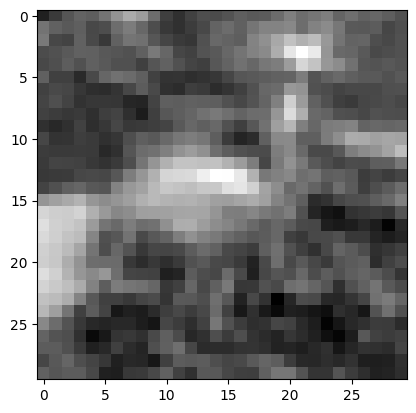

In [6]:
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.show()

In [7]:
conv = nn.Conv2d(in_channels= 3, out_channels= 1, kernel_size=3, padding=1)
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape , output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 1, 32, 32]))

In [8]:
with torch.no_grad():
    conv.bias.zero_()
    conv.weight.fill_(1.0 / 9.0)

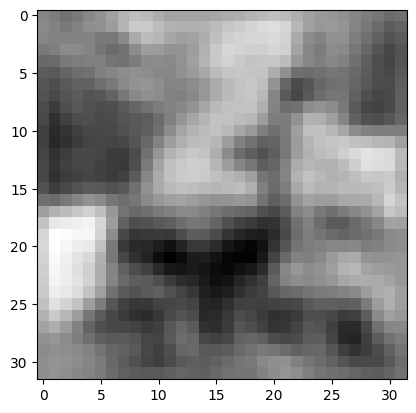

In [9]:
output = conv(img.unsqueeze(0))
plt.imshow(output[0,0].detach(), cmap= 'gray')
plt.show()

In [10]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1)
with torch.no_grad():
    conv.weight[:] = torch.tensor([[-1, 0, 1],
                                  [-1, 0, -1],
                                  [-1, 0, 1]])
    conv.bias.zero_()

In [11]:
pool = nn.MaxPool2d(2)
output = pool(img.unsqueeze(0))

img.unsqueeze(0).shape , output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 3, 16, 16]))

In [12]:
model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding= 1),
    nn.Tanh(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 8, kernel_size=3, padding=1),
    nn.Tanh(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(8*8*8, 32),
    nn.Tanh(),
    nn.Linear(32, 2),

)

In [13]:
class Net(nn.Module):
    def __init__ (self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.act1 = nn.Tanh()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.act2 = nn.Tanh()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(8*8*8, 32)
        self.act3 = nn.Tanh()
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = self.pool1(self.act1(self.conv1(x)))
        out = self.pool2(self.act2(self.conv2(out)))
        out = out.view(-1, 8*8*8)
        out = out(self.act3(self.fc1(out)))
        out = self.fc2(out)
        return out

In [14]:
import torch.nn.functional as F

class Net(nn.Module):
    def __init__ (self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8*8*8, 32)
        self.fc2= nn.Linear(32, 2)
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8*8*8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out


    
    

In [15]:
model = Net()
model(img.unsqueeze(0))

tensor([[0.0591, 0.1404]], grad_fn=<AddmmBackward0>)

In [16]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size = 64, shuffle = False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size = 64, shuffle = False)

def validate (model, train_loader, val_loader):
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0

        with torch.no_grad():
            for imgs, labels in loader:
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1)
                total +=labels.shape[0]
                correct += int((predicted == labels).sum())
        print("accuracy{}: {:.2f}".format(name, correct / total))
validate(model , train_loader, val_loader)

accuracytrain: 0.46
accuracyval: 0.46


In [17]:
torch.save(model.state_dict(), data_path + 'birds_vs_airplanes.pt')